## 1. Write code to build a CNN with 4 convolutional layers, 4 pooling layers and 1 fully connected layer.

In [1]:
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt

2025-11-24 02:30:15.466534: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763951415.669911      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763951415.735310      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
EPOCHS = 10

# loading data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshaping and normalizing for CNN
X_train_cnn = X_train.reshape((X_train.shape[0], 28, 28, 1)) / 255
X_test_cnn = X_test.reshape((X_test.shape[0], 28, 28, 1)) / 255

# normalizing for feedforward (no reshape needed, Flatten layer handles it)
X_train_ff = X_train / 255
X_test_ff = X_test / 255

# checking the shape after reshaping
print("CNN data shape:", X_train_cnn.shape)
print("Feedforward data shape:", X_train_ff.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN data shape: (60000, 28, 28, 1)
Feedforward data shape: (60000, 28, 28)


In [3]:
def build_cnn():
    model = Sequential()
    model.add(
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1))
    )
    model.add(MaxPool2D(2, 2))
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPool2D(2, 2))
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPool2D(2, 2))
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPool2D(2, 2))
    model.add(Flatten())
    model.add(Dense(100, activation="relu"))
    model.add(Dense(10, activation="softmax"))
    model.compile(
        loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
    )
    return model

In [4]:
model = build_cnn()
model.summary()
model.fit(X_train_cnn, y_train, epochs=EPOCHS, validation_split=0.1)
# evaluating the model on test set
loss, accuracy = model.evaluate(X_test_cnn, y_test)
print(f"Task 1 - CNN Test Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763951433.094877      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763951433.095679      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,182 (391.34 KB)

 Trainable params: 100,182 (391.34 KB)

...

Epoch 1/10


I0000 00:00:1763951436.544657      60 service.cc:148] XLA service 0x7d841000d140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763951436.545069      60 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763951436.545087      60 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763951436.852393      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


  58/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3127 - loss: 2.0105

I0000 00:00:1763951439.275674      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8629 - loss: 0.4239 - val_accuracy: 0.9838 - val_loss: 0.0529
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9831 - loss: 0.0567 - val_accuracy: 0.9862 - val_loss: 0.0474
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9885 - loss: 0.0365 - val_accuracy: 0.9900 - val_loss: 0.0358
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9919 - loss: 0.0275 - val_accuracy: 0.9912 - val_loss: 0.0337
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9928 - loss: 0.0227 - val_accuracy: 0.9902 - val_loss: 0.0344
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9937 - loss: 0.0209 - val_accuracy: 0.9878 - val_loss: 0.0431
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9952 - loss: 0.0151 - val_accuracy: 0.9930 - val_loss: 0.0313
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9960 - loss: 0.0119 - val_accura

# 2. Build a feedforward neural network model (feel free to choose the number of layers, etc.) and train it on MNSIT. How does the performance of the feedforward neural network model compare to the CNN on the test set?

In [5]:
def build_ffnn():
    """Build a Feedforward NN model with 3 hidden layers"""
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))
    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(256, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(10, activation="softmax"))
    model.compile(
        loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
    )
    return model

In [6]:
FeedForwardModel = build_ffnn()
FeedForwardModel.summary()

# train the feedforward model
ff_history = FeedForwardModel.fit(X_train_ff, y_train, epochs=EPOCHS, validation_split=0.1)

# evaluating the model on test set
ff_loss, ff_accuracy = FeedForwardModel.evaluate(X_test_ff, y_test)
print(f"Task 2 - Feedforward NN Test Accuracy: {ff_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8607 - loss: 0.4452 - val_accuracy: 0.9662 - val_loss: 0.1105
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9613 - loss: 0.1281 - val_accuracy: 0.9747 - val_loss: 0.0881
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9724 - loss: 0.0944 - val_accuracy: 0.9757 - val_loss: 0.0834
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9749 - loss: 0.0827 - val_accuracy: 0.9783 - val_loss: 0.0840
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9794 - loss: 0.0682 - val_accuracy: 0.9757 - val_loss: 0.0803
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9790 - val_loss: 0.0710
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9842 - loss: 0.0535 - val_accuracy: 0.9828 - val_loss: 0.0669
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9863 - loss: 0.0457 -

In [7]:
print(f"CNN Accuracy: {accuracy:.4f}")
print(f"Feedforward Accuracy: {ff_accuracy:.4f}")
accuracy_diff = (accuracy - ff_accuracy) * 100
if accuracy > ff_accuracy:
    print(f"CNN is {accuracy_diff:.2f}% more accurate")
else:
    print(f"Feedforward is {-accuracy_diff:.2f}% more accurate")

CNN Accuracy: 0.9904
Feedforward Accuracy: 0.9805
CNN is 0.99% more accurate


Although both models achieve high test accuracy, the CNN outperforms the feedforward NN having fewer parameters(100,182 vs 567,434) and achieving higher test accuracy. This is due to how the convolutional layers preserve spatial relationships, better learning the local patterns for digit classification.

The feedforward network treats each pixel as an independent feature. This means that we lose spatial information and requires the model to learn more parameters to learn patterns. To combat the model's weaknesses and learn more generalized features, I added dropout to the feedforward model so it could get results that were comparable to the CNN.


## 3. Given the MNSIT training data. Take half the size of the training data and train your CNN. What is the effect on accuracy on the test set compared to part 1.? What happens when you only train on 5% of the training data?

In [8]:
half_size = len(X_train_cnn) // 2
indices_50 = np.random.choice(len(X_train_cnn), half_size, replace=False)
X_train_50 = X_train_cnn[indices_50]
y_train_50 = y_train[indices_50]
model_50 = build_cnn()

print(f"Training with {len(X_train_50)} samples (50%)")
model_50.fit(X_train_50, y_train_50, epochs=EPOCHS, validation_split=0.1)
loss_50, accuracy_50 = model_50.evaluate(X_test_cnn, y_test)
print(f"50% Data - Test Accuracy: {accuracy_50:.4f}")

Training with 30000 samples (50%)
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7908 - loss: 0.6167 - val_accuracy: 0.9700 - val_loss: 0.0986
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9752 - loss: 0.0763 - val_accuracy: 0.9807 - val_loss: 0.0638
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9858 - loss: 0.0466 - val_accuracy: 0.9817 - val_loss: 0.0616
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9880 - loss: 0.0341 - val_accuracy: 0.9867 - val_loss: 0.0542
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9843 - val_loss: 0.0586
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accuracy: 0.9857 - val_loss: 0.0547
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9945 - loss: 0.0182 - val_accuracy: 0.9883 - val_loss: 0.0594
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9948

## What happens when you only train on 5% of the training data?

In [9]:
five_percent_size = len(X_train_cnn) // 20
indices_05 = np.random.choice(len(X_train_cnn), five_percent_size, replace=False)
X_train_05 = X_train_cnn[indices_05]
y_train_05 = y_train[indices_05]
model_05 = build_cnn()

print(f"Training with {len(X_train_05)} samples (5%)")
model_05.fit(X_train_05, y_train_05, epochs=EPOCHS, validation_split=0.1)
loss_05, accuracy_05 = model_05.evaluate(X_test_cnn, y_test)
print(f"5% Data - Test Accuracy: {accuracy_05:.4f}")

Training with 3000 samples (5%)
Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.3919 - loss: 1.7973 - val_accuracy: 0.8867 - val_loss: 0.3699
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8734 - loss: 0.3941 - val_accuracy: 0.9367 - val_loss: 0.2255
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9344 - loss: 0.2144 - val_accuracy: 0.9433 - val_loss: 0.2130
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9512 - loss: 0.1480 - val_accuracy: 0.9500 - val_loss: 0.1758
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9593 - loss: 0.1231 - val_accuracy: 0.9667 - val_loss: 0.1031
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9808 - loss: 0.0751 - val_accuracy: 0.9700 - val_loss: 0.1127
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9834 - loss: 0.0497 - val_accuracy: 0.9700 - val_loss: 0.1040
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9845 - loss: 0.0424 -

In [10]:
print(f"100% Data ({len(X_train_cnn)} samples): {accuracy:.4f}")
print(f"50% Data  ({len(X_train_50)} samples): {accuracy_50:.4f}")
print(f"5% Data   ({len(X_train_05)} samples): {accuracy_05:.4f}")
print("\nAccuracy drop from 100% baseline:")
print(f"  50% data: {(accuracy - accuracy_50) * 100:.2f}% drop")
print(f"  5% data:  {(accuracy - accuracy_05) * 100:.2f}% drop")

100% Data (60000 samples): 0.9904
50% Data  (30000 samples): 0.9881
5% Data   (3000 samples): 0.9664

Accuracy drop from 100% baseline:
  50% data: 0.23% drop
  5% data:  2.40% drop


Reducing the training data, accuracy dropped. However, the accuracy drop was very minimal indicating how data-efficient CNNs are. We can see how for simple classification tasks, CNN's can achieve very strong performance without requiring very large datasets, though we risk the chance of overfitting.

## 4. Given your trained CNN model on the training data. Take two images in the test set that were previously correctly classified. Now add noise to the images (gaussian noise, salt and pepper noise, etc.). Are you able to now fool the trained CNN? If yes, show which images were fooled by the CNN. If not, provide a sample of the images you produced. Report the noise parameters that you have tested.

In [11]:
predictions = model.predict(X_test_cnn)
predicted_classes = np.argmax(predictions, axis=1)
correct_mask = predicted_classes == y_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
# Select 2 correctly classified images (one from digit 3 and one from digit 7 for variety)
correctly_classified_indices = np.where(correct_mask)[0]
digit_3_indices = [i for i in correctly_classified_indices if y_test[i] == 3]
digit_7_indices = [i for i in correctly_classified_indices if y_test[i] == 7]
selected_indices = [digit_3_indices[0], digit_7_indices[0]]
selected_images = X_test_cnn[selected_indices]
selected_labels = y_test[selected_indices]

print("\nSelected images for noise testing:")
print(f"  Image 1: Index {selected_indices[0]}, True Label: {selected_labels[0]}")
print(f"  Image 2: Index {selected_indices[1]}, True Label: {selected_labels[1]}")


Selected images for noise testing:
  Image 1: Index 18, True Label: 3
  Image 2: Index 0, True Label: 7


In [13]:
def add_gaussian_noise(image, mean=0.0, std=0.1):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0.0, 1.0)

def add_salt_pepper_noise(image, amount=0.05):
    noisy_image = image.copy()
    # Salt (white pixels)
    num_salt = int(amount * image.size / 2)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy_image[coords[0], coords[1], coords[2]] = 1
    # Pepper (black pixels)
    num_pepper = int(amount * image.size / 2)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy_image[coords[0], coords[1], coords[2]] = 0
    return noisy_image

In [14]:
# Test different noise types and parameters
noise_tests = [
    ("Gaussian (std=0.2)", lambda img: add_gaussian_noise(img, std=0.2)),
    ("Gaussian (std=0.5)", lambda img: add_gaussian_noise(img, std=0.5)),
    ("Gaussian (std=0.8)", lambda img: add_gaussian_noise(img, std=0.8)),
    ("Salt&Pepper (0.1)", lambda img: add_salt_pepper_noise(img, amount=0.1)),
    ("Salt&Pepper (0.3)", lambda img: add_salt_pepper_noise(img, amount=0.3)),
    ("Salt&Pepper (0.5)", lambda img: add_salt_pepper_noise(img, amount=0.5)),
]

In [15]:
fooled_examples = []
total_tests = 0
fooled_count = 0

for img_idx, (img, true_label) in enumerate(zip(selected_images, selected_labels)):
    print(f"\n--- Image {img_idx + 1} (True Label: {true_label}) ---")
    orig_pred = model.predict(img.reshape(1, 28, 28, 1))
    orig_class = np.argmax(orig_pred)

    for noise_name, noise_func in noise_tests:
        total_tests += 1
        noisy_img = noise_func(img)
        noisy_pred = model.predict(noisy_img.reshape(1, 28, 28, 1))
        noisy_class = np.argmax(noisy_pred)
        noisy_conf = np.max(noisy_pred)

        fooled = noisy_class != true_label
        if fooled:
            fooled_count += 1
            print(
                f"FOOLED by {noise_name}: {true_label} → {noisy_class} (conf: {noisy_conf:.4f})"
            )
            fooled_examples.append(
                {
                    "img_idx": img_idx,
                    "original": img,
                    "noisy": noisy_img,
                    "true_label": true_label,
                    "predicted": noisy_class,
                    "noise_name": noise_name,
                    "confidence": noisy_conf,
                }
            )


--- Image 1 (True Label: 3) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
FOOLED by Salt&Pepper (0.3): 3 → 5 (conf: 0.4679)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

--- Image 2 (True Label: 7) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
FOOLED by Gaussian (std=0.5): 7 → 2 (conf: 0.1759)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
FOOLED by Gaussian (std=0.8): 7 → 6 (conf: 0.2622)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [16]:
# Results summary
print(f"Total tests: {total_tests}")
print(
    f"Successfully fooled: {fooled_count} times ({fooled_count / total_tests * 100:.1f}%)"
)
print(
    f"Resistant: {total_tests - fooled_count} times ({(total_tests - fooled_count) / total_tests * 100:.1f}%)"
)

Total tests: 12
Successfully fooled: 3 times (25.0%)
Resistant: 9 times (75.0%)


Saved: task4_fooled_examples.png


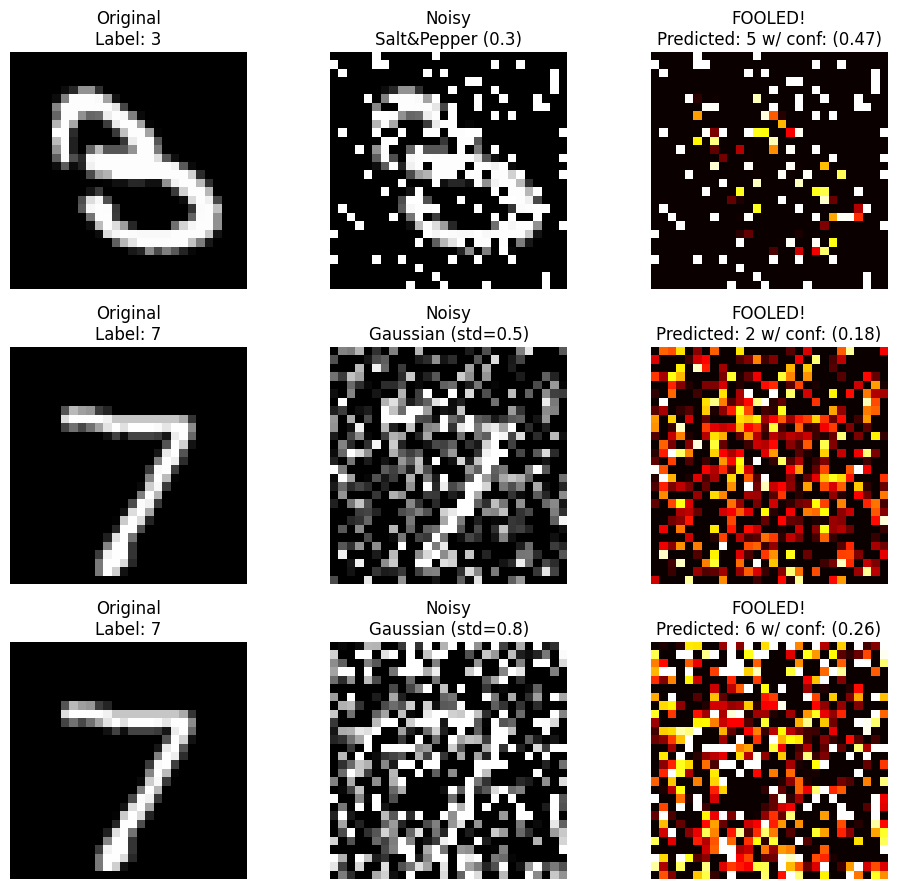

In [17]:
num_show = min(6, len(fooled_examples))
fig, axes = plt.subplots(num_show, 3, figsize=(10, 3 * num_show))
if num_show == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_show):
    ex = fooled_examples[idx]

    # Original
    axes[idx, 0].imshow(ex["original"].reshape(28, 28), cmap="gray")
    axes[idx, 0].set_title(f"Original\nLabel: {ex['true_label']}")
    axes[idx, 0].axis("off")

    # Noisy
    axes[idx, 1].imshow(ex["noisy"].reshape(28, 28), cmap="gray")
    axes[idx, 1].set_title(f"Noisy\n{ex['noise_name']}")
    axes[idx, 1].axis("off")

    # Result
    diff = np.abs(ex["original"] - ex["noisy"])
    axes[idx, 2].imshow(diff.reshape(28, 28), cmap="hot")
    axes[idx, 2].set_title(
        f"FOOLED!\nPredicted: {ex['predicted']} w/ conf: ({ex['confidence']:.2f})"
    )
    axes[idx, 2].axis("off")

plt.tight_layout()
plt.savefig("task4_fooled_examples.png", dpi=150, bbox_inches="tight")
print("Saved: task4_fooled_examples.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
✓ Saved: task4_noise_samples.png


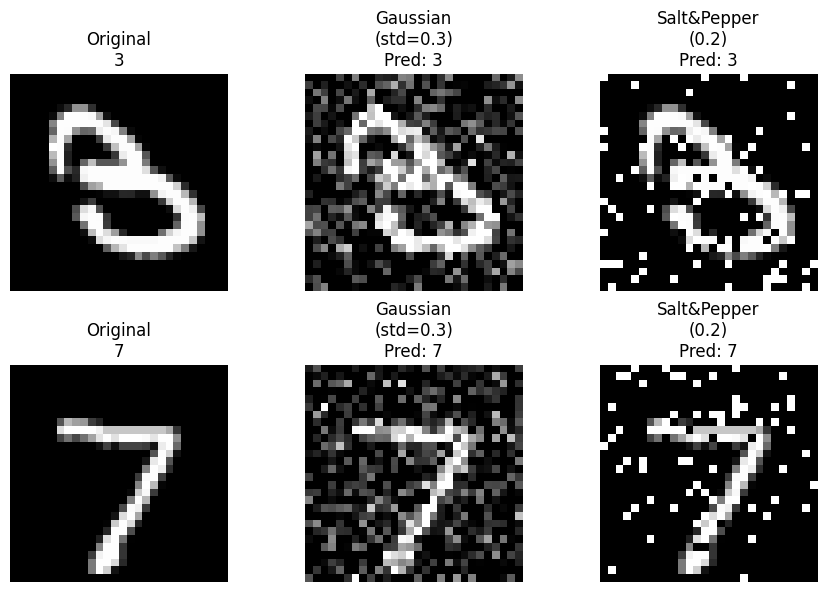

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for i in range(2):
    img = selected_images[i]
    true_label = selected_labels[i]

    # Original
    axes[i, 0].imshow(img.reshape(28, 28), cmap="gray")
    axes[i, 0].set_title(f"Original\n{true_label}")
    axes[i, 0].axis("off")

    # Different noises
    noisy_imgs = [
        add_gaussian_noise(img, std=0.3),
        add_salt_pepper_noise(img, amount=0.2),
    ]
    titles = ["Gaussian\n(std=0.3)", "Salt&Pepper\n(0.2)"]

    for j, (noisy, title) in enumerate(zip(noisy_imgs, titles)):
        pred = model.predict(noisy.reshape(1, 28, 28, 1))
        pred_class = np.argmax(pred)
        axes[i, j + 1].imshow(noisy.reshape(28, 28), cmap="gray")
        axes[i, j + 1].set_title(f"{title}\nPred: {pred_class}")
        axes[i, j + 1].axis("off")

plt.tight_layout()
plt.savefig("task4_noise_samples.png", dpi=150, bbox_inches="tight")
print("✓ Saved: task4_noise_samples.png")

We were able to fool the CNN, but only with higher noise levels. Lower noise samples with Guassian=0.2 and SaltPepper=0.1 did not cause misclassification. When the model was fooled, the confidence in the prediction was much lower than when compared to correct predictions. 

CNN's resist moderate noise quite well. This is most likely due to the pooling layers which average local features and help the model generalize.